In [56]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *
from NanoparticlesSAM.particle_seg import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
pickels = glob.glob('results/*pkl')

df_list = []

for file in pickels:
    df_list.append(pd.read_pickle(file))

df = pd.concat(df_list)
df['nm_per_pixel']  = df['nm_estimated_radius'] / df['estimated_radius']

In [47]:
df.head()

,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel
0,"[[False, False, False, False, False, False, Fa...",27494,"[210, 170, 188, 184]",1.019673,"[[379.66666666666663, 232.55555555555554]]",0.993511,"[0, 0, 804, 644]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",749,27494.0,...,93.550051,"(379.66666666666663, 232.55555555555554)",189.256440,183.140656,111.661299,110.389060,216.105974,Tina 01,Tina,1.18
1,"[[False, False, False, False, False, False, Fa...",27255,"[232, 372, 186, 180]",1.014682,"[[334.99999999999994, 406.30555555555554]]",0.992509,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",737,27255.0,...,93.142557,"(334.99999999999994, 406.30555555555554)",191.908833,180.000000,113.226211,109.908217,212.400000,Tina 01,Tina,1.18
2,"[[False, False, False, False, False, False, Fa...",29272,"[858, 593, 191, 192]",1.018185,"[[945.4166666666667, 692.0833333333334]]",0.992649,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",771,29272.0,...,96.527545,"(945.4166666666667, 692.0833333333334)",195.645087,190.065765,115.430601,113.902503,224.277603,Tina 01,Tina,1.18
3,"[[False, False, False, False, False, False, Fa...",29319,"[473, 585, 192, 193]",1.012717,"[[513.6666666666666, 656.3611111111111]]",0.991783,"[0, 317, 804, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",775,29319.0,...,96.605008,"(513.6666666666666, 656.3611111111111)",196.086716,192.000000,115.691162,113.993909,226.560000,Tina 01,Tina,1.18
4,"[[False, False, False, False, False, False, Fa...",29222,"[610, 374, 196, 189]",1.015703,"[[633.1388888888889, 406.30555555555554]]",0.990733,"[477, 317, 803, 643]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",775,29222.0,...,96.445070,"(633.1388888888889, 406.30555555555554)",199.180822,189.525040,117.516685,113.805182,223.639547,Tina 01,Tina,1.18


/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='nm_feret_radius', ylabel='Count'>

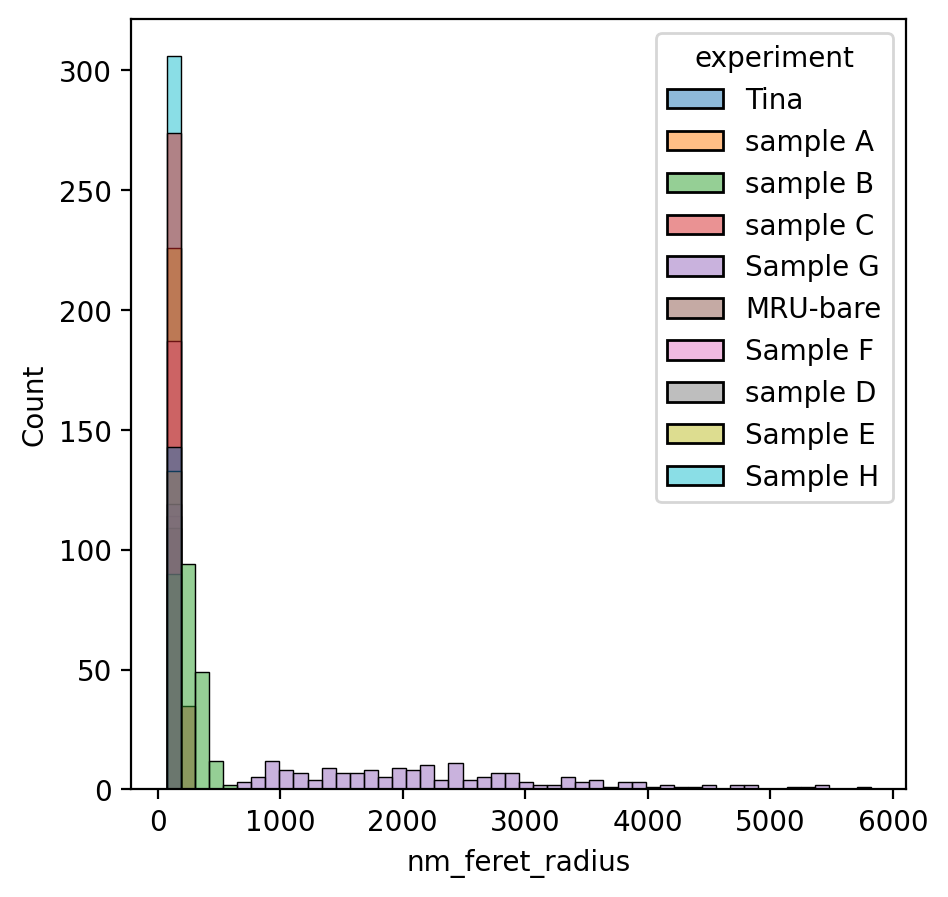

In [48]:
plt.figure(figsize=(5,5), dpi=200)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment', bins=50)

In [49]:
exclusion_list = df[df.nm_feret_radius > 250].img_name.unique().tolist() + ['H-7']

In [50]:
df_filtered = df[~df['img_name'].isin(exclusion_list)]

In [53]:
df_filtered['nm_per_pixel'] = df_filtered.nm_estimated_radius / df_filtered.estimated_radius
df_filtered['hough_radius'] = df_filtered.apply(lambda x: get_hough_radius(x['smooth_mask'], 90, 130, x['nm_per_pixel'], True), axis=1)

/var/folders/hx/cphylf_x45bdc9bx9rm660lh0000gn/T/ipykernel_7856/3255974913.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['nm_per_pixel'] = df_filtered.nm_estimated_radius / df_filtered.estimated_radius
/var/folders/hx/cphylf_x45bdc9bx9rm660lh0000gn/T/ipykernel_7856/3255974913.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['hough_radius'] = df_filtered.apply(lambda x: get_hough_radius(x['smooth_mask'], 90, 130, x['nm_per_pixel'], True), axis=1)


/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='hough_radius', ylabel='Count'>

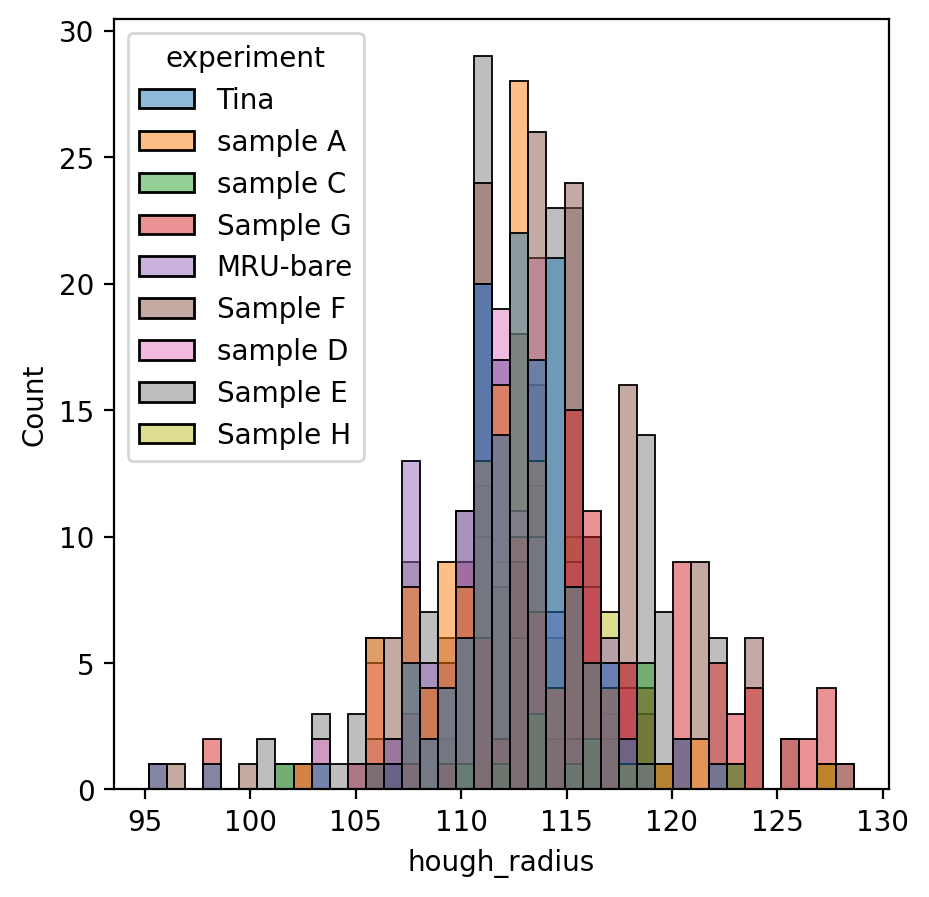

In [54]:
plt.figure(figsize=(5,5), dpi=200)
plot_df = df_filtered.dropna()
sns.histplot(data=plot_df, x='hough_radius', hue='experiment')

<Figure size 1000x1000 with 0 Axes>

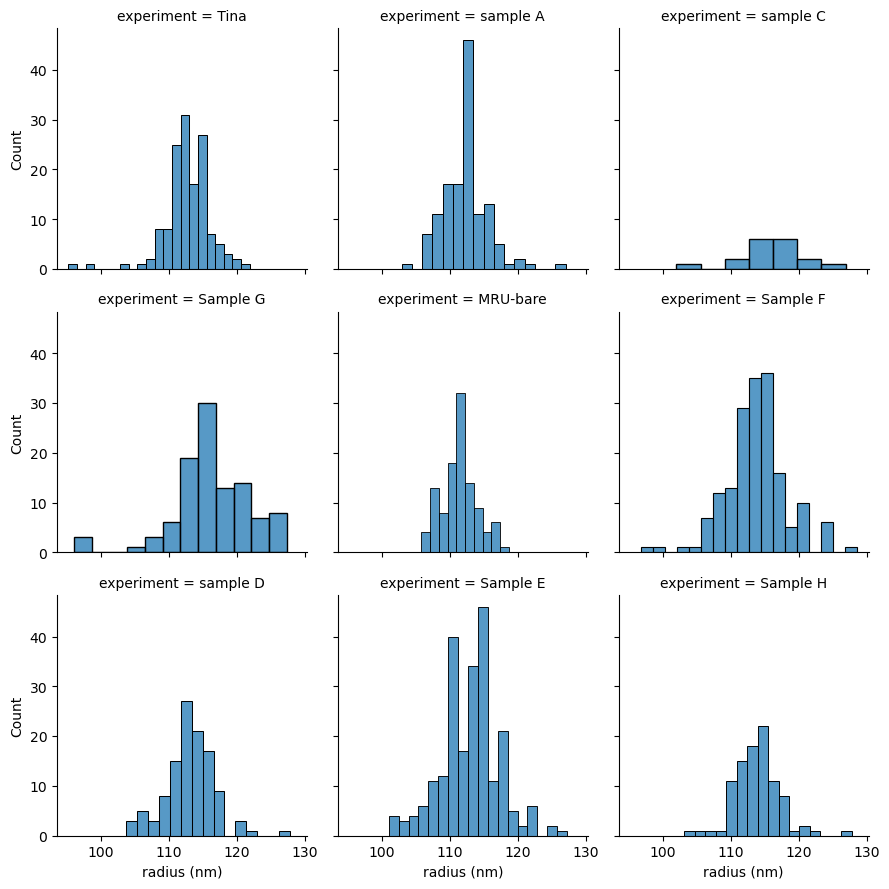

In [77]:
plt.figure(figsize=(5,5), dpi=200)
g = sns.FacetGrid(plot_df, col='experiment', col_wrap=3)
g.map(sns.histplot, 'hough_radius')
g.set_axis_labels("radius (nm)", "Count")

In [63]:
experiment_df = df_filtered.reset_index().pivot(columns='experiment', values='hough_radius')
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
#experiment_df = remove_outliers_df(experiment_df)
experiment_df.head()

experiment,MRU-bare,Sample E,Sample F,Sample G,Sample H,Tina,sample A,sample B,sample C,sample D
0,114.46,111.0,109.0,112.84,112.42,110.92,117.26,NaN,115.0,112.0
1,112.1,111.0,116.0,120.12,113.96,113.28,110.11,NaN,119.0,115.0
2,112.1,116.0,113.0,116.48,118.58,113.28,112.97,NaN,119.0,111.0
3,113.28,120.0,113.0,127.4,120.12,114.46,114.4,NaN,119.0,106.0
4,116.82,112.0,111.0,123.76,110.88,115.64,121.55,NaN,119.0,115.0


In [65]:
analyze_samples(experiment_df, 'MRU-bare', alpha=0.001)

,Sample E,Sample F,Sample G,Sample H,Tina,sample A,sample C,sample D
thickness,1.632175,2.412667,5.017793,2.23193,1.280623,0.814269,4.963242,1.623271
CI_lower,0.319974,0.965219,2.942605,0.771735,-0.010181,-0.491045,-0.087897,0.175983
CI_upper,2.944376,3.860115,7.09298,3.692124,2.571426,2.119583,10.01438,3.070559
p_value,0.000046,0.0,0.0,0.000001,0.001094,0.03875,0.001166,0.000235
significance,Significant,Significant,Significant,Significant,Not significant,Not significant,Not significant,Significant
significance_level,99.95,99.95,99.95,99.95,99.95,99.95,99.95,99.95
SEM,0.395015,0.435251,0.617956,0.436431,0.387579,0.391807,1.294321,0.433565
DOF,312.754239,280.492906,146.562846,178.81643,246.542347,239.998547,18.484078,207.168119
N_sample,225,174,104,94,140,133,18,113
N_ref,109,109,109,109,109,109,109,109


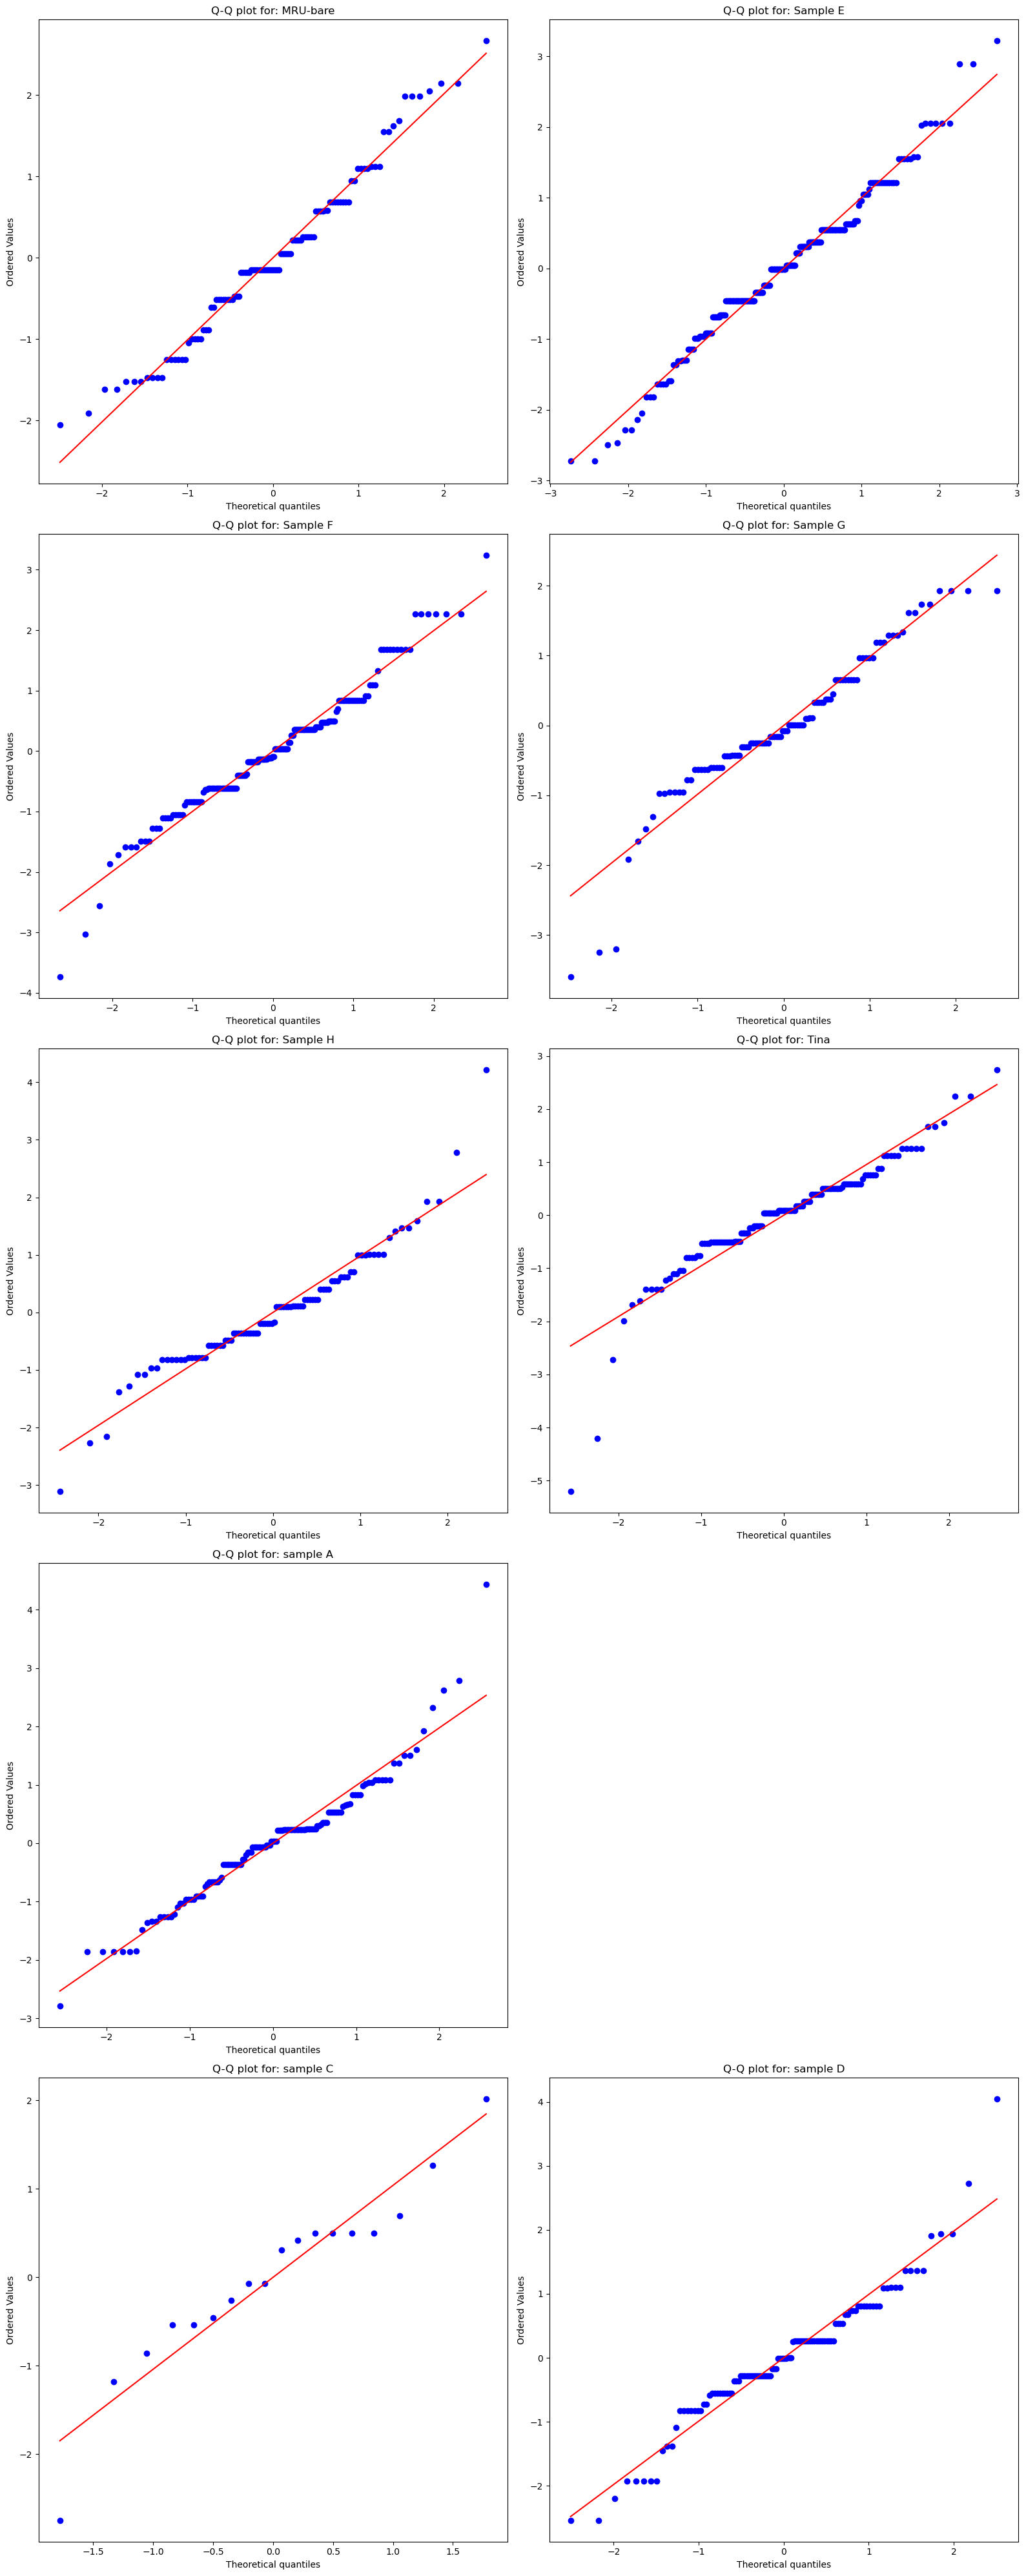

In [66]:
plot_quantiles(experiment_df)